# Theta reference panels (Berke lab)

Six probe maps for one run epoch, used to pick a theta reference electrode.

| Panel | What it is |
|---|---|
| Phase of peak firing | Circular mean theta phase of every pooled spike, in that electrode's own theta |
| Spike-locking strength R | How tightly those spikes cluster in phase (0 = uniform, 1 = all identical) |
| Median theta power | Median of \|z\|² over the epoch |
| Phase offset from max-power electrode | Mean theta phase difference from the reference |
| Power correlation with max-power electrode | Pearson r of the power envelopes |
| Power vs. speed correlation | Pearson r of theta power against running speed |

**Phase convention is peak-referenced: 0/360° = theta PEAK, 180° = TROUGH**, matching the
hippocampal literature (Mizuseki et al. 2009 *Neuron* 64:267–280; 2011 *Nat Neurosci*
14:1174–1181). CA1 pyramidal cells fire near the trough, so a good pyramidal-layer electrode
should land near **180°**.

**Berke lab only.** These sessions use a single probe model whose `rel_x`/`rel_y` are unique
across the whole session, so the probe is drawn true to scale. Frank lab sessions put several
identical probes on the same coordinates and need a different layout — use
`spyglass_hexmaze.spike_theta_phase` for those.

Marks on every panel: **white star** = electrode is the peak channel of at least one good unit,
**yellow outline** = max-power electrode (default reference for phase-relative metrics), **red outline** = electrodes already
saved in `HexMazeThetaReference`, **white box** = bad channel.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

import spyglass.common as sgc

from spyglass_hexmaze.hex_maze_theta import HexMazeThetaV1, HexMazeThetaReference
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition
from spyglass_hexmaze.spikesorting_helpers import (
    fetch_good_units,
    electrodes_with_units,
    fetch_electrode_geometry,
)

# Which session to look at. Berke lab sessions have exactly one run epoch, "00_r1".
NWB_FILE_NAME = "IM-1947_20260415_.nwb"
INTERVAL = "00_r1"

SUBSAMPLE = 50       # keep every Nth sample for the correlation metrics (~25 Hz), to save RAM
SPEED_THRESH = 5.0   # cm/s above which the rat counts as running

[2026-09-11 18:58:03,511][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306


## Compute

One pass over the stored analytic signal, using `HexMazeThetaV1.iter_complex()` so only one
electrode is in memory at a time. For each electrode we read its complex theta `z`, then
derive everything from it:

- `power = |z|²` and `phase = mod(angle(z), 2π)` — the peak-referenced phase
- the **mean phase vector** — one unit-length arrow per spike, pointing at that
  spike's theta phase, all added up and divided by the spike count. Its *direction*
  is the average phase and its *length* (0–1) is how tightly the spikes cluster.
- a subsampled copy of power and phase, kept for the correlation metrics

Spikes are binned onto the theta sample grid first, so "look up the phase at every spike time"
becomes a single dot product against the whole column — no per-spike array is ever built.

In [2]:
def nearest_sample(spike_times, theta_time):
    """Index of the nearest theta sample for every spike that falls inside the epoch.

    Parameters:
        spike_times (np.ndarray): Spike times in seconds, whole session
        theta_time (np.ndarray): Theta sample times in seconds, this epoch only

    Returns:
        np.ndarray: One index into theta_time per spike inside the epoch. Spikes outside
            the epoch are dropped, so this can be shorter than spike_times.
    """
    st = np.asarray(spike_times, dtype=float)
    inside = st[(st >= theta_time[0]) & (st <= theta_time[-1])]
    # searchsorted gives the sample just after each spike; keep whichever neighbor is closer
    right = np.clip(np.searchsorted(theta_time, inside), 1, len(theta_time) - 1)
    left = right - 1
    return np.where(inside - theta_time[left] <= theta_time[right] - inside, left, right)


def bin_spikes(spike_times, theta_time):
    """Count spikes into their nearest theta sample.

    Turns a list of spike times into a weight per theta sample, so every "at each spike"
    quantity below becomes a weighted sum over the electrode's column.

    Parameters:
        spike_times (np.ndarray): Sorted spike times in seconds, whole session
        theta_time (np.ndarray): Theta sample times in seconds, this epoch only

    Returns:
        np.ndarray: Same length as theta_time, holding the spike count per sample.
            Spikes outside the epoch are dropped.
    """
    return np.bincount(nearest_sample(spike_times, theta_time),
                       minlength=len(theta_time)).astype(float)


def compute_metrics(nwb_file_name, interval, verbose=True):
    """The six per-electrode metrics for one (session, run epoch).

    Parameters:
        nwb_file_name (str): e.g. "IM-1871_20250731_.nwb"
        interval (str): Run interval theta was computed on, "00_r1" for Berke sessions
        verbose (bool): Print progress. Default True.

    Returns:
        tuple: (metrics, info).
            metrics (pd.DataFrame): One row per electrode, indexed by electrode name (str),
                with rel_x / rel_y / is_bad, the six metric columns, and the two spike phase
                metrics repeated over running spikes only (_run). Bad channels are NaN.
            info (dict): session_label, reference, unit_electrodes, saved_reference,
                n_units, n_spikes, minutes.
    """
    key = {"nwb_file_name": nwb_file_name, "target_interval_list_name": interval}
    theta = HexMazeThetaV1 & key
    if len(theta) != 1:
        raise ValueError(f"expected 1 HexMazeThetaV1 entry, found {len(theta)}")

    # get theta sample times (same for all electrodes) and electrode IDs
    theta_time = theta.fetch_time()
    electrode_ids = theta.get_electrode_ids()
    names = [str(e) for e in electrode_ids]
    minutes = (theta_time[-1] - theta_time[0]) / 60
    if verbose:
        print(f"{nwb_file_name} {interval}: {len(names)} electrodes, {minutes:.0f} min")

    # get every spike from every good unit, pooled
    units = fetch_good_units(nwb_file_name, verbose=verbose)
    spike_times = np.sort(np.concatenate([np.asarray(s, dtype=float) for s in units["spike_times"]]))
    spike_counts = bin_spikes(spike_times, theta_time)
    n_spikes = int(spike_counts.sum())
    if verbose:
        print(f"  {len(units)} good units, {n_spikes} spikes inside the epoch")

    # get running speed from decode dataframe
    epoch = (sgc.TaskEpoch & {"nwb_file_name": nwb_file_name,
                              "interval_list_name": interval}).fetch("epoch")
    decode = HexMazeDecodedPosition & {"nwb_file_name": nwb_file_name, "epoch": int(epoch[0])}
    # A session can have more than one decoding parameter set. 
    # Speed is the same in all of them, so taking the first is safe here
    decode_df = (HexMazeDecodedPosition & decode.fetch("KEY")[0]).fetch1_dataframe()
    speed = np.asarray(
        decode_df["speed"].reindex(pd.Index(theta_time), method="nearest").values, dtype=float)

    # The same spike counts, zeroed everywhere the rat was not running. Phase locking is a
    # running phenomenon, so the two spike phase metrics are computed both ways below.
    running_counts = np.where(speed >= SPEED_THRESH, spike_counts, 0.0)
    n_spikes_run = int(running_counts.sum())
    if verbose:
        print(f"  {n_spikes_run} of those while running (speed > {SPEED_THRESH:.0f} cm/s)")

    # One pass over the electrodes:
    # iter_complex yields one electrode's analytic signal at a time over a single open file
    # handle, so memory stays at one column instead of the ~19 GB the whole table would take.
    median_power, mean_phase_vector, mean_phase_vector_run = {}, {}, {}
    power_sub, phase_sub = {}, {}
    for i, (electrode, z) in enumerate(theta.iter_complex(electrode_ids)):
        name = str(electrode)

        power = np.abs(z) ** 2
        median_power[name] = float(np.median(power))

        # Both spike phase metrics come the mean phase vector.
        #
        # Angles cannot be averaged directly (plain mean of 359 deg and 1 deg is 180 deg)
        # So point a unit-length arrow at each spike's phase, add the arrows tip-to-tail, 
        # and divide by the number of spikes. Then:
        #   its DIRECTION is the average phase    -> peak_firing_phase_deg
        #   its LENGTH (0 to 1) is the clustering -> peak_firing_R
        #      length 1 = every spike at the identical phase
        #      length 0 = spikes spread evenly around the circle, no phase preference at all
        #
        # z/|z| IS that unit arrow (it equals exp(i*phase)) with no trig needed, and because
        # spike_counts holds the number of spikes in each theta sample, this one dot product
        # adds one arrow per spike in a single pass over the column.
        unit_vector = z / np.abs(z)
        mean_phase_vector[name] = complex(np.dot(spike_counts, unit_vector)) / n_spikes
        # The same sum over running spikes only -- running_counts is zero everywhere else
        mean_phase_vector_run[name] = complex(np.dot(running_counts, unit_vector)) / n_spikes_run

        # Subsampled copies for the correlation metrics below
        power_sub[name] = power[::SUBSAMPLE]
        phase_sub[name] = np.mod(np.angle(z[::SUBSAMPLE]), 2 * np.pi)
        if verbose and (i + 1) % 50 == 0:
            print(f"  read {i + 1}/{len(electrode_ids)} electrodes")

    median_power = pd.Series(median_power)
    power_sub = pd.DataFrame(power_sub)[names]
    phase_sub = pd.DataFrame(phase_sub)[names]

    # Choose the electrodee with the highest median theta power as a reference for now
    # (This will NOT be our theta reference electrode, but we need a reference to see phase offsets etc)
    geometry = fetch_electrode_geometry(nwb_file_name)
    is_bad = geometry["is_bad"].reindex(names).fillna(False).values
    good_names = [n for n, bad in zip(names, is_bad) if not bad]
    reference = median_power[good_names].idxmax()

    # Set up df of metrics for each electrode
    metrics = pd.DataFrame(index=pd.Index(names, name="electrode"))

    # 1. Phase of peak firing: the DIRECTION of the mean phase vector
    metrics["peak_firing_phase_deg"] = [
        np.degrees(np.angle(mean_phase_vector[n])) % 360 for n in names]

    # 2. Locking strength: the LENGTH of that same vector, already scaled to 0-1
    metrics["peak_firing_R"] = [np.abs(mean_phase_vector[n]) for n in names]

    # Both of those again from running spikes only
    metrics["peak_firing_phase_deg_run"] = [
        np.degrees(np.angle(mean_phase_vector_run[n])) % 360 for n in names]
    metrics["peak_firing_R_run"] = [np.abs(mean_phase_vector_run[n]) for n in names]

    # 3. Median theta power over the epoch
    metrics["theta_power"] = median_power.reindex(names)

    # 4. Phase offset from the reference: circular mean of (phase - reference phase). 
    # Done as the angle of the mean unit vector so the 0/360 wrap works.
    reference_phase = phase_sub[reference].values
    metrics["phase_offset_deg"] = np.degrees(np.angle(np.mean(
        np.exp(1j * (phase_sub.values - reference_phase[:, None])), axis=0)))

    # 5. Power correlation with the reference: Pearson r of the two power envelopes.
    metrics["power_corr"] = power_sub.corrwith(power_sub[reference])

    # 6. Power vs speed: Pearson r of theta power against running speed (exluding inf/nan samples)
    speed_sub = speed[::SUBSAMPLE][: len(power_sub)]
    finite = np.isfinite(speed_sub)
    power_values = power_sub.values[finite]
    speed_values = speed_sub[finite]
    power_centered = power_values - power_values.mean(0)
    speed_centered = speed_values - speed_values.mean()
    metrics["power_speed_corr"] = (
        (power_centered * speed_centered[:, None]).sum(0)
        / np.sqrt((power_centered ** 2).sum(0) * (speed_centered ** 2).sum()))

    # Get probe geometry and blank out bad channels
    metrics = metrics.join(geometry[["rel_x", "rel_y", "is_bad"]])
    metrics["is_bad"] = metrics["is_bad"].fillna(False)
    metric_columns = [c for c in metrics.columns if c not in ("rel_x", "rel_y", "is_bad")]
    metrics.loc[metrics["is_bad"], metric_columns] = np.nan

    saved = HexMazeThetaReference & key
    info = {
        "session_label": f"{nwb_file_name.replace('_.nwb', '')}_{interval}",
        "nwb_file_name": nwb_file_name,
        "reference": reference,
        "unit_electrodes": electrodes_with_units(units),
        "saved_reference": sorted({int(e) for ids in saved.fetch("electrode_ids") for e in ids}),
        "n_units": len(units),
        "n_spikes": n_spikes,
        "minutes": minutes,
    }
    if verbose:
        print(f"  reference (max power) electrode: {reference}")
    return metrics, info

In [3]:
metrics, info = compute_metrics(NWB_FILE_NAME, INTERVAL)
metrics.head()

IM-1947_20260415_.nwb 00_r1: 236 electrodes, 80 min
IM-1947_20260415_.nwb: 256 good units from 21 sort groups (v1)
  256 good units, 4406976 spikes inside the epoch
  3009862 of those while running (speed > 5 cm/s)
  read 50/236 electrodes
  read 100/236 electrodes
  read 150/236 electrodes
  read 200/236 electrodes
  reference (max power) electrode: 84


,peak_firing_phase_deg,peak_firing_R,peak_firing_phase_deg_run,peak_firing_R_run,theta_power,phase_offset_deg,power_corr,power_speed_corr,rel_x,rel_y,is_bad
electrode,,,,,,,,,,,
7,196.166570,0.106336,216.672259,0.094277,34680.843812,-77.253027,0.290856,0.313951,80.0,212.5,False
8,193.341161,0.101004,211.953257,0.094237,32585.464132,-85.137805,0.214876,0.347078,80.0,237.5,False
9,191.343042,0.088239,206.899996,0.092327,30628.148364,-92.891474,0.165282,0.360840,80.0,262.5,False
10,190.468671,0.075416,201.027829,0.091413,31187.849354,-100.830817,0.186929,0.355686,80.0,287.5,False
11,189.002522,0.070458,196.100531,0.090731,30905.814820,-106.111779,0.210668,0.344054,80.0,312.5,False


## Plot

One box per electrode at its true `rel_x` / `rel_y`, colored by the metric.

In [4]:
def box_size(values):
    """Smallest nonzero gap between neighbouring site positions, so boxes tile without overlap."""
    gaps = np.diff(np.unique(values[np.isfinite(values)]))
    gaps = gaps[gaps > 0]
    return gaps.min() if len(gaps) else 1.0


def draw_panel(ax, metrics, values, cmap, cbar_label, title, clim, info):
    """Draw the probe as one box per electrode, colored by `values`.

    Parameters:
        ax (matplotlib.axes.Axes): Axes to draw on
        metrics (pd.DataFrame): Output of compute_metrics
        values (np.ndarray): One value per row of `metrics`, in the same order
        cmap (str): Matplotlib colormap name
        cbar_label (str): Colorbar label
        title (str): Panel title
        clim (tuple): (vmin, vmax) for the colormap, or None to autoscale
        info (dict): Second return value of compute_metrics, for the stars and outlines

    Returns:
        None
    """
    width = box_size(metrics["rel_x"].values)
    height = box_size(metrics["rel_y"].values)

    colormap = plt.colormaps[cmap].copy()
    colormap.set_bad("white")           # bad channels were set to NaN, so they draw white
    boxes = [Rectangle((x - width / 2, y - height / 2), width, height)
             for x, y in zip(metrics["rel_x"], metrics["rel_y"])]
    collection = PatchCollection(boxes, cmap=colormap)
    collection.set_array(np.ma.masked_invalid(np.asarray(values, dtype=float)))
    if clim is not None:
        collection.set_clim(*clim)
    ax.add_collection(collection)

    # White star = electrode is the peak channel of at least one good unit
    starred = metrics.index.astype(int).isin(set(info["unit_electrodes"]))
    if starred.any():
        ax.scatter(metrics.loc[starred, "rel_x"], metrics.loc[starred, "rel_y"],
                   marker="*", s=70, c="white", edgecolors="black", linewidths=0.6,
                   zorder=5, label="Has good unit(s)")

    # Yellow outline = max-power electrode, the reference for panels 4 and 5
    if info["reference"] in metrics.index:
        row = metrics.loc[info["reference"]]
        ax.add_patch(Rectangle((row["rel_x"] - width / 2, row["rel_y"] - height / 2),
                               width, height, fill=False, edgecolor="yellow", linewidth=2,
                               zorder=6, label="Max-power electrode"))

    # Red outline = already saved in HexMazeThetaReference for this epoch
    for i, electrode in enumerate(info["saved_reference"]):
        name = str(int(electrode))
        if name in metrics.index:
            row = metrics.loc[name]
            ax.add_patch(Rectangle((row["rel_x"] - width / 2, row["rel_y"] - height / 2),
                                   width, height, fill=False, edgecolor="red", linewidth=2,
                                   zorder=7, label="Saved reference" if i == 0 else None))

    # Electrode numbers (up-and-right of center so they don't overlap with the stars)
    for name, row in metrics.iterrows():
        if row["is_bad"]:
            continue
        ax.text(row["rel_x"] + 0.22 * width, row["rel_y"] + 0.22 * height, name,
                ha="center", va="center", fontsize=4, color="white", fontweight="bold",
                path_effects=[pe.withStroke(linewidth=1.0, foreground="black")], zorder=8)

    ax.set_xlim(metrics["rel_x"].min() - width, metrics["rel_x"].max() + width)
    ax.set_ylim(metrics["rel_y"].min() - height, metrics["rel_y"].max() + height)
    # Scale based on probe geometry
    x_span = (metrics["rel_x"].max() - metrics["rel_x"].min()) + 2 * width
    y_span = (metrics["rel_y"].max() - metrics["rel_y"].min()) + 2 * height
    ax.set_box_aspect(y_span / x_span)
    ax.set_ylabel("rel_y (µm)")
    ax.set_title(title, fontsize=10)
    plt.colorbar(collection, ax=ax, label=cbar_label, fraction=0.02, pad=0.01)


def plot_metrics(metrics, info, save_dir=None):
    """The six-panel probe figure for one session.

    Parameters:
        metrics (pd.DataFrame): First return value of compute_metrics
        info (dict): Second return value of compute_metrics
        save_dir (str or Path): Folder to save a PDF into. Default None = don't save.

    Returns:
        matplotlib.figure.Figure
    """
    reference = info["reference"]
    # Log the power so one very strong electrode does not flatten the whole colorbar
    plot_data = metrics.copy()
    plot_data["theta_power_log10"] = np.log10(metrics["theta_power"])

    # Symmetric limits so the sign of the speed correlation reads off the colormap
    speed_limit = np.nanmax(np.abs(metrics["power_speed_corr"]))

    # (column, colormap, colorbar label, clim, title)
    panels = [
        ("peak_firing_phase_deg", "twilight", "Phase (deg)", (0, 360),
         "Phase of peak firing (all spikes) (0/360 = theta peak, 180 = trough)"),
        ("peak_firing_R", "magma", "R", (0, np.nanmax(metrics["peak_firing_R"])),
         "Spike–theta locking strength R (all spikes)"),
        ("theta_power_log10", "viridis", "Theta power (log10)", None,
         "Median theta power"),
        ("phase_offset_deg", "twilight", "Phase offset (deg)", (-180, 180),
         f"Theta phase offset from max-power electrode {reference}"),
        ("power_corr", "magma", "Corr with ref power", (0, 1),
         f"Theta power correlation with max-power electrode {reference}"),
        ("power_speed_corr", "RdBu_r", "Corr(power, speed)", (-speed_limit, speed_limit),
         "Theta power vs. running speed correlation"),
    ]

    fig_height = 3.0 * len(panels) + 0.6
    fig, axes = plt.subplots(len(panels), 1, figsize=(16, fig_height))
    for ax, (column, cmap, cbar_label, clim, title) in zip(axes, panels):
        draw_panel(ax, plot_data, plot_data[column].values,
                   cmap, cbar_label, title, clim, info)
    # Legend above the first panel so it does not sit on top of any electrodes
    axes[0].legend(loc="lower left", bbox_to_anchor=(0, 1.18), ncol=3,
                   fontsize=8, frameon=False)
    axes[-1].set_xlabel("rel_x (µm)")

    # tight_layout works in figure fractions, so the suptitle gap has to be converted from
    # inches or it lands on top of the first panel's title
    fig.tight_layout(rect=[0, 0, 1, 1 - 0.5 / fig_height])
    fig.suptitle(f"{info['session_label']} — {info['n_units']} good units, "
                 f"{info['n_spikes']} spikes, {info['minutes']:.0f} min",
                 fontsize=14, y=1 - 0.12 / fig_height)

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        path = save_dir / f"{info['session_label']}_theta_panels.pdf"
        fig.savefig(path, bbox_inches="tight")
        print(f"saved {path}")
    return fig

saved figures/IM-1947_20260415_00_r1/IM-1947_20260415_00_r1_theta_panels.pdf


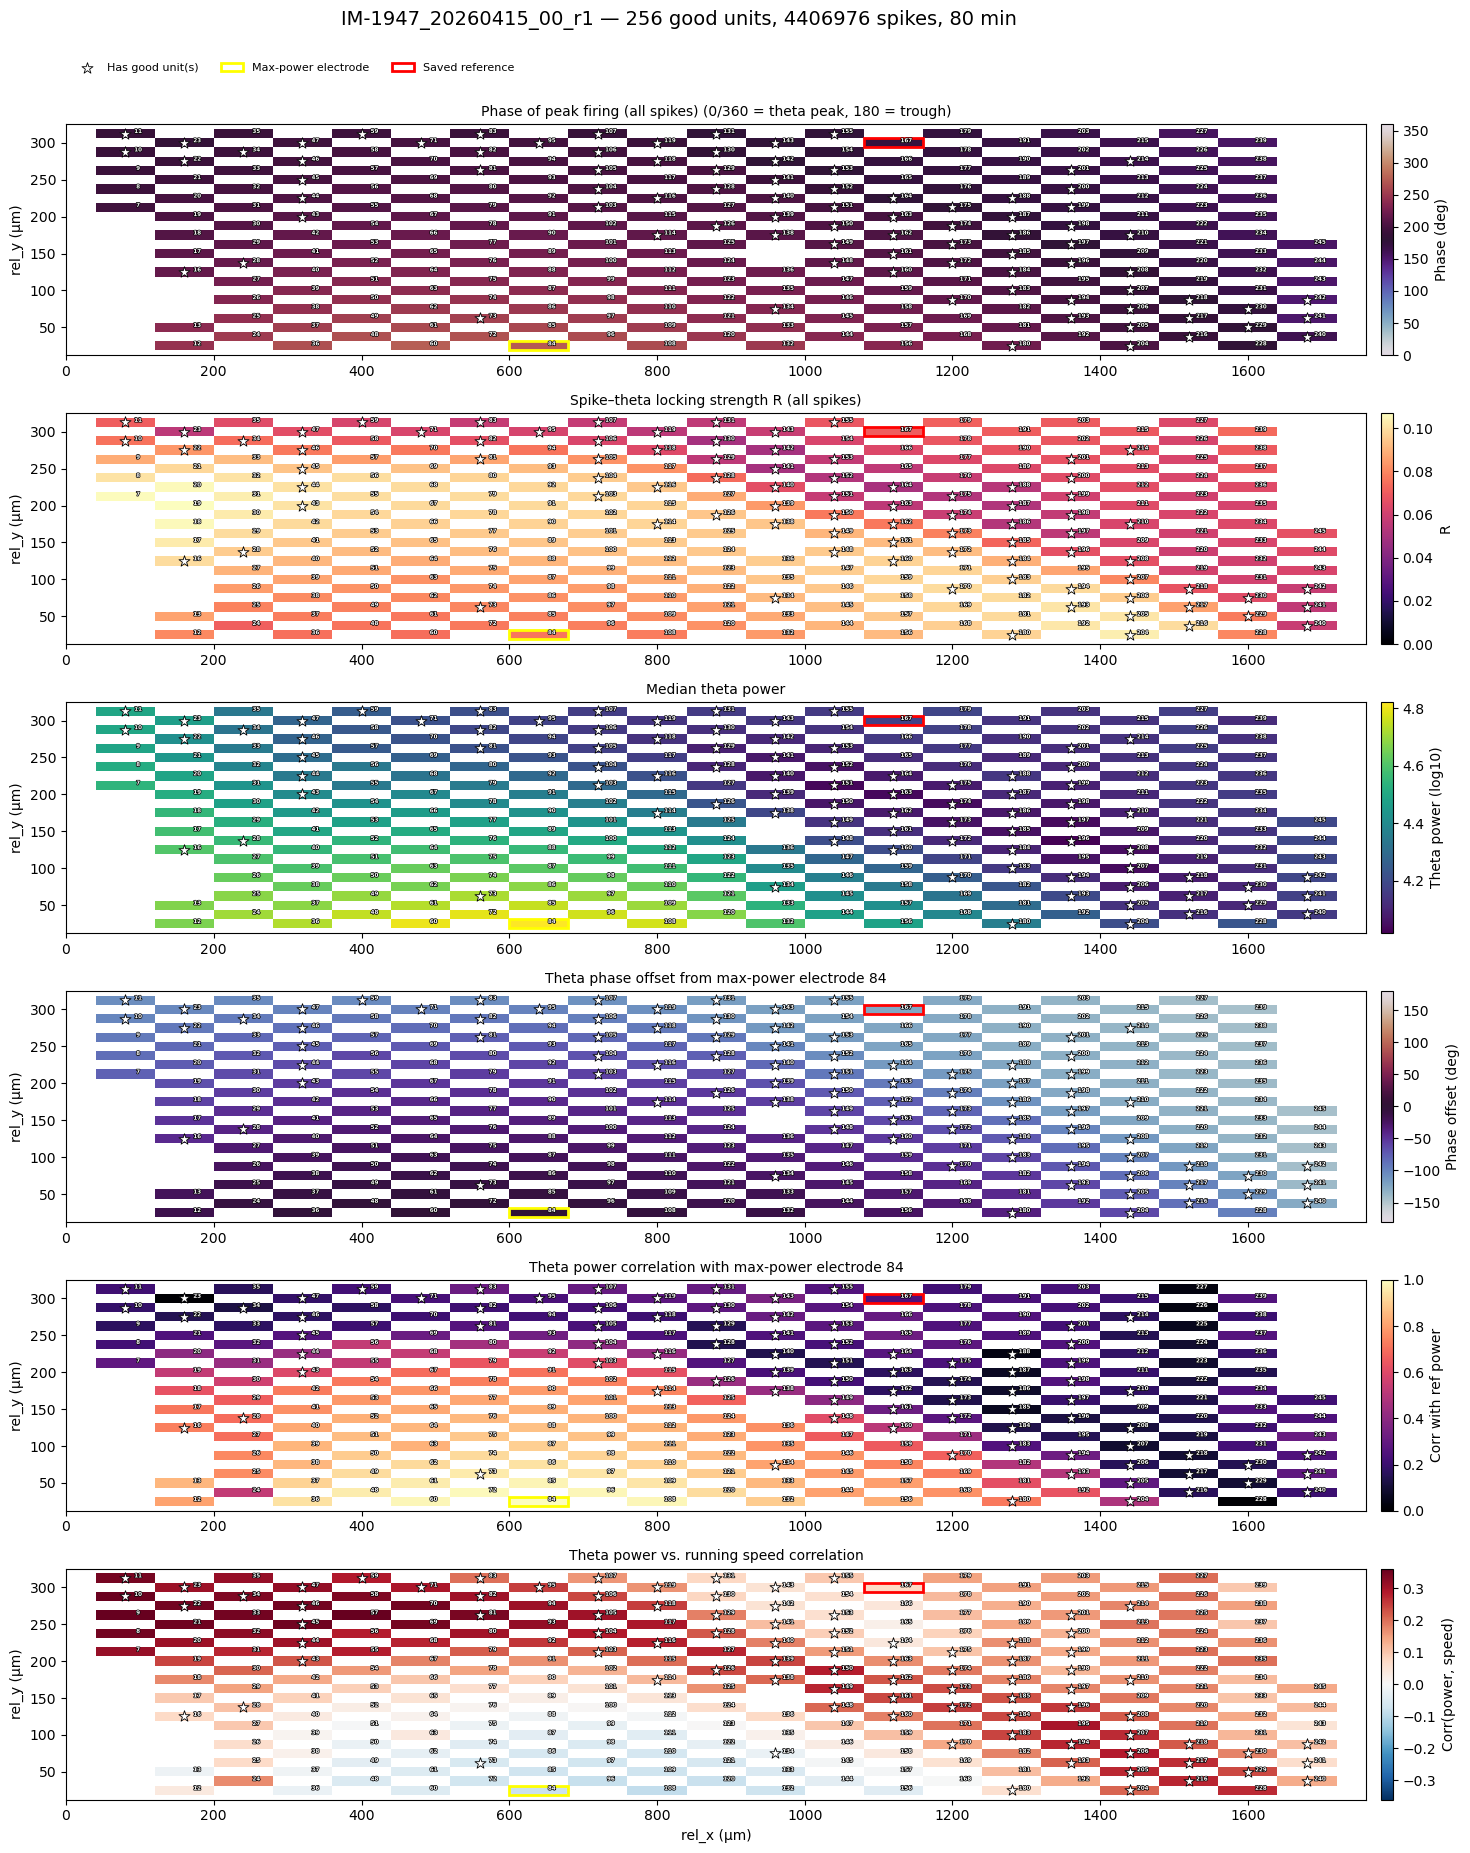

In [5]:
fig = plot_metrics(metrics, info, save_dir=Path("figures") / info["session_label"])

In [6]:
# Rank the electrodes by how close their pooled spike phase is to 180 deg -- the theta trough,
# where CA1 pyramidal cells fire. Ranking is on the RUNNING spikes, with the all-spike columns
# alongside for comparison.
CANDIDATE_COLUMNS = ["deg_from_180_run", "peak_firing_phase_deg_run", "peak_firing_R_run",
                     "deg_from_180", "peak_firing_phase_deg", "peak_firing_R",
                     "theta_power", "rel_y"]


def rank_candidates(metrics):
    """Electrodes ranked by how close their running spike phase is to the theta trough.

    Phase is already in [0, 360) and 180 sits exactly half a cycle from the 0/360 wrap, so the
    distance from the trough is just |phase - 180| with no wraparound to handle. R rides along
    because the phase means nothing without it: an electrode whose spikes are not locked to theta
    at all can sit at 180 deg by chance. theta_power and rel_y are there to check that the pick is
    in the layer you expect rather than an isolated site.

    Parameters:
        metrics (pd.DataFrame): First return value of compute_metrics

    Returns:
        pd.DataFrame: Good electrodes only (bad channels dropped, their metrics are NaN), sorted
            closest-first, holding CANDIDATE_COLUMNS.
    """
    candidates = metrics[~metrics["is_bad"].astype(bool)].copy()
    candidates["deg_from_180_run"] = (candidates["peak_firing_phase_deg_run"] - 180).abs()
    candidates["deg_from_180"] = (candidates["peak_firing_phase_deg"] - 180).abs()
    return candidates.sort_values("deg_from_180_run")[CANDIDATE_COLUMNS]


candidates = rank_candidates(metrics)
top = candidates.iloc[0]
print(f"closest to 180 deg while running: electrode {candidates.index[0]} "
      f"({top['peak_firing_phase_deg_run']:.0f} deg, R = {top['peak_firing_R_run']:.3f}; "
      f"all spikes {top['peak_firing_phase_deg']:.0f} deg, R = {top['peak_firing_R']:.3f})")
candidates.head(20)

closest to 180 deg while running: electrode 177 (180 deg, R = 0.086; all spikes 174 deg, R = 0.064)


,deg_from_180_run,peak_firing_phase_deg_run,peak_firing_R_run,deg_from_180,peak_firing_phase_deg,peak_firing_R,theta_power,rel_y
electrode,,,,,,,,
177,0.000289,179.999711,0.085660,6.210068,173.789932,0.063725,14152.515422,262.5
166,0.196730,180.196730,0.087107,6.142897,173.857103,0.063722,14313.012279,275.0
240,0.637254,179.362746,0.077179,17.394038,162.605962,0.058144,14283.895784,37.5
188,1.043841,181.043841,0.074025,7.405040,172.594960,0.053840,13980.562110,225.0
198,1.362173,181.362173,0.080175,6.848378,173.151622,0.056826,11780.151284,187.5
167,1.461603,178.538397,0.090744,5.649277,174.350723,0.070267,14859.865246,300.0
210,2.185154,177.814846,0.082838,8.367714,171.632286,0.062430,12345.857588,175.0
178,2.470045,177.529955,0.088700,6.901176,173.098824,0.068435,14955.964986,287.5
199,2.497419,177.502581,0.082559,8.531918,171.468082,0.060489,12381.748891,212.5


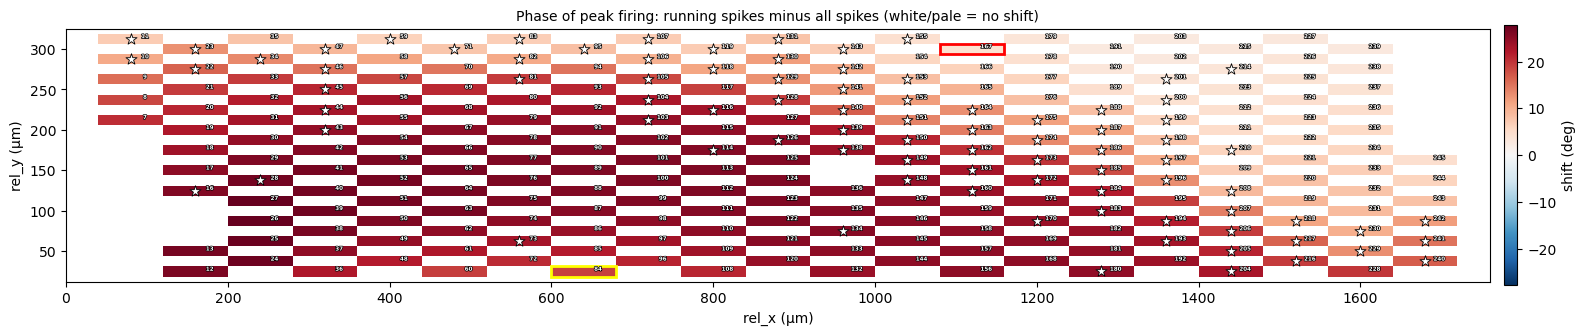

|shift| deg: median 21.2, 90th pct 25.9, max 27.8
|shift| vs running R, correlation: 0.735 (negative = the weakly locked electrodes shift most)


In [7]:
# Shift in the phase of peak firing between running spikes and all spikes, per electrode. wrapped to [-180, 180]
shift_deg = ((metrics["peak_firing_phase_deg_run"]
              - metrics["peak_firing_phase_deg"] + 180) % 360) - 180

plot_data = metrics.copy()
plot_data["phase_shift_deg"] = shift_deg
# Diverging colormap with symmetric limits, so zero shift is the neutral middle and the sign
# (running phase later vs earlier than the all-spikes phase) reads straight off the color
limit = np.nanmax(np.abs(shift_deg))

fig, ax = plt.subplots(figsize=(16, 3.2))
draw_panel(ax, plot_data, plot_data["phase_shift_deg"].values, "RdBu_r", "shift (deg)",
           "Phase of peak firing: running spikes minus all spikes (white/pale = no shift)",
           (-limit, limit), info)
ax.set_xlabel("rel_x (µm)")
fig.tight_layout()
plt.show()

# The shift is the rest spikes pulling the pooled mean off the running one, so it should be
# small where running locking is strong. Print the two together to check that.
print(f"|shift| deg: median {shift_deg.abs().median():.1f}, "
      f"90th pct {shift_deg.abs().quantile(0.9):.1f}, max {shift_deg.abs().max():.1f}")
print(f"|shift| vs running R, correlation: "
      f"{shift_deg.abs().corr(metrics['peak_firing_R_run'], method='spearman'):.3f} "
      f"(negative = the weakly locked electrodes shift most)")

## Evaluate a reference electrode pick

The panels above tell you *where* to pick. This section checks one **candidate pick** — the
average of the electrodes you chose — against the two things we use theta phase for. Both are
drawn twice: **running** in the top row, **unfiltered** in the bottom row.

| Panel | What it is | What good looks like |
|---|---|---|
| Spike theta phase | Pooled spikes from all good units, binned by the reference phase, plus one arrow per unit | A clear hump near **180°** (CA1 cells fire at the trough of pyramidal-layer theta) |
| Decode distance vs. theta phase | Mean decoded distance ahead/behind the rat in each phase bin, over two cycles | A smooth one-cycle sweep, i.e. theta sequences are locked to this reference |

Running means speed above `SPEED_THRESH`, and for decode distance also `spatial_cov` below
`SPATIAL_COV_MAX` — a decode spread over the whole maze carries no phase information.
Unfiltered is every sample in the epoch, so the pair shows how much of the effect is the
filtering and how much is the reference.

For a pick of more than one electrode the summary also gives the **phase correlation** between
the chosen channels (mean Pearson r of cos(phase) over channel pairs). Averaging only helps if
the channels carry the same theta, so r should be close to 1.

Only the chosen electrodes are read off disk, so this runs in seconds rather than the ~4 minutes
the panels above take.

In [8]:
# Spike phase and decode distance are each computed twice: RUNNING only (theta, phase locking
# and theta sequences are all running phenomena) and UNFILTERED (every sample in the epoch), so
# you can see what the filtering is doing to the result.
SPATIAL_COV_MAX = 200.0   # only trust decodes at least this tight (spatial_cov below it)
PHASE_BINS = 24           # 15 deg bins for the spike phase rose
DIST_BINS = 18            # 20 deg bins for decode distance vs phase


def evaluate_reference(nwb_file_name, interval, electrode_ids, verbose=True):
    """Check one candidate reference electrode set for a (session, run epoch).

    The reference is the AVERAGE of the chosen electrodes' complex analytic signal, which is
    how HexMazeThetaReference combines them downstream (averaging z, not the phases, so
    in-phase theta adds and noise cancels). A single-electrode pick is just that electrode.

    Spike phase and decode distance are each computed under two masks:
        running -- speed above SPEED_THRESH, and for decode also spatial_cov below
                   SPATIAL_COV_MAX, since a decode spread over the whole maze carries no
                   phase information
        all     -- every sample in the epoch, no filtering

    Parameters:
        nwb_file_name (str): e.g. "IM-1947_20260415_.nwb"
        interval (str): Run interval theta was computed on, "00_r1" for Berke sessions
        electrode_ids (list): The electrodes you want to check, ints or strings ("57")
        verbose (bool): Print the summary numbers. Default True.

    Returns:
        dict: Everything plot_reference_evaluation() draws --
            electrode_ids: the pick, as ints
            phase_corr: mean Pearson r between the chosen channels, over all channel pairs
                (NaN for a single electrode)
            phase_bin_centers_deg / dist_bin_centers_deg: bin centers for the two panel types
            spike_phase: {"running": stats, "all": stats}, each holding counts (spikes per
                phase bin), n_spikes, pooled_phase_deg, pooled_R, and per_unit as
                (mean_angle_rad, R, n_spikes) per unit
            decode_distance: {"running": stats, "all": stats}, each holding mean and sem per
                phase bin (cm), corr (circular-linear correlation with phase), peak_phase_deg
                (bin where distance is most positive) and n_samples
    """
    key = {"nwb_file_name": nwb_file_name, "target_interval_list_name": interval}
    theta = HexMazeThetaV1 & key
    if len(theta) != 1:
        raise ValueError(f"expected 1 HexMazeThetaV1 entry, found {len(theta)}")
    electrode_ids = [int(e) for e in electrode_ids]
    if verbose:
        print(f"{nwb_file_name} {interval}: checking electrodes {electrode_ids}")

    # Read only the chosen electrodes, then average them into the reference. iter_complex hands
    # back plain numpy over one open file handle, so the shared time column is read once here
    # rather than once per electrode.
    theta_time = theta.fetch_time()
    channel_z = np.column_stack([z for _, z in theta.iter_complex(electrode_ids)])
    reference_z = channel_z.mean(axis=1)
    reference_phase = np.mod(np.angle(reference_z), 2 * np.pi)   # 0 = peak, pi = trough
    # Unit phase vector at every sample: z/|z| is exp(i*phase) with no trig needed
    reference_unit = reference_z / np.abs(reference_z)
    # Phase bin of every sample, computed once here so the loops below only index into it
    spike_bin = np.minimum((reference_phase * (PHASE_BINS / (2 * np.pi))).astype(int),
                           PHASE_BINS - 1)
    dist_bin = np.minimum((reference_phase * (DIST_BINS / (2 * np.pi))).astype(int),
                          DIST_BINS - 1)

    # Do the chosen channels carry the same theta? Pearson r between channels, averaged over
    # channel pairs: close to 1 = same theta, so averaging them adds up instead of cancelling
    # out. A single electrode has no pair, hence NaN. We correlate cos(phase) rather than phase
    # itself because phase is a 0-360 sawtooth whose wrap alone drags r down -- two channels a
    # steady 20 deg apart score only 0.68 on raw phase but cos(20 deg) = 0.94 this way.
    if len(electrode_ids) > 1:
        correlations = np.corrcoef(np.cos(np.angle(channel_z)), rowvar=False)
        phase_corr = float(correlations[np.triu_indices(len(electrode_ids), k=1)].mean())
    else:
        phase_corr = np.nan

    # Speed, decode distance and coverage on the theta sample grid. All three come out of ONE
    # nearest-neighbour reindex: matching a few million theta samples against the decode index
    # is the slowest arithmetic in here, so it is done once instead of once per column.
    epoch = (sgc.TaskEpoch & {"nwb_file_name": nwb_file_name,
                              "interval_list_name": interval}).fetch("epoch")
    decode = HexMazeDecodedPosition & {"nwb_file_name": nwb_file_name, "epoch": int(epoch[0])}
    # A session can have more than one decoding parameter set; take the first
    decode_df = (HexMazeDecodedPosition & decode.fetch("KEY")[0]).fetch1_dataframe()
    aligned = decode_df[["speed", "decode_distance", "spatial_cov"]].reindex(
        pd.Index(theta_time), method="nearest")
    speed = aligned["speed"].to_numpy(dtype=float)
    decode_distance = aligned["decode_distance"].to_numpy(dtype=float)
    spatial_cov = aligned["spatial_cov"].to_numpy(dtype=float)
    running = speed >= SPEED_THRESH          # NaN speeds compare False, so they drop out here

    # ---- spike phase in the reference theta ---------------------------------------------------
    # One arrow per spike, pointing at the reference phase that spike landed on. Per unit we
    # keep the mean arrow (direction = preferred phase, length = locking strength R); pooled
    # over units we keep the phase histogram and the summed arrow. Each unit's spikes are
    # located once and then counted into both the running and the unfiltered version.
    units = fetch_good_units(nwb_file_name, verbose=verbose)
    spike_phase = {name: {"counts": np.zeros(PHASE_BINS), "n_spikes": 0,
                          "per_unit": [], "resultant": 0j}
                   for name in ("running", "all")}
    for spike_times in units["spike_times"]:
        epoch_samples = nearest_sample(spike_times, theta_time)
        for name, samples in (("all", epoch_samples),
                              ("running", epoch_samples[running[epoch_samples]])):
            if samples.size == 0:            # a unit can be silent for this whole mask
                continue
            arrows = reference_unit[samples]
            mean_arrow = arrows.mean()
            stats = spike_phase[name]
            stats["per_unit"].append((np.angle(mean_arrow), np.abs(mean_arrow), samples.size))
            stats["resultant"] += arrows.sum()
            stats["n_spikes"] += samples.size
            stats["counts"] += np.bincount(spike_bin[samples], minlength=PHASE_BINS)
    for stats in spike_phase.values():
        # Direction of the summed arrow is the mean phase, its length over the spike count is R
        resultant = stats.pop("resultant")
        stats["pooled_phase_deg"] = np.degrees(np.angle(resultant)) % 360
        stats["pooled_R"] = np.abs(resultant) / stats["n_spikes"]

    # ---- decode distance vs the reference phase ------------------------------------------------
    finite_distance = np.isfinite(decode_distance)   # NaN distances cannot be binned either way
    dist_bin_centers_deg = (np.arange(DIST_BINS) + 0.5) * 360 / DIST_BINS
    decode_stats = {}
    for name, mask in (("running", finite_distance & running & (spatial_cov < SPATIAL_COV_MAX)),
                       ("all", finite_distance)):
        kept_bin, kept_distance = dist_bin[mask], decode_distance[mask]
        # Mean and SEM per phase bin, from the bin counts and the bin sums
        counts = np.bincount(kept_bin, minlength=DIST_BINS).astype(float)
        sums = np.bincount(kept_bin, weights=kept_distance, minlength=DIST_BINS)
        sums_sq = np.bincount(kept_bin, weights=kept_distance ** 2, minlength=DIST_BINS)
        mean = sums / counts
        # Sample variance from those raw moments, then SEM = sd / sqrt(n)
        sem = np.sqrt((sums_sq - counts * mean ** 2) / (counts - 1) / counts)

        # Mardia's circular-linear correlation: how much of the distance phase explains, from
        # the correlation of distance with cos(phase) and with sin(phase). 0 = nothing, 1 = all.
        cos_phase, sin_phase = np.cos(reference_phase[mask]), np.sin(reference_phase[mask])
        rxc = np.corrcoef(kept_distance, cos_phase)[0, 1]
        rxs = np.corrcoef(kept_distance, sin_phase)[0, 1]
        rcs = np.corrcoef(cos_phase, sin_phase)[0, 1]

        decode_stats[name] = {
            "mean": mean,
            "sem": sem,
            "corr": float(np.sqrt((rxc ** 2 + rxs ** 2 - 2 * rxc * rxs * rcs) / (1 - rcs ** 2))),
            "peak_phase_deg": float(dist_bin_centers_deg[np.nanargmax(mean)]),
            "n_samples": int(mask.sum()),
        }

    if verbose:
        print(f"  phase correlation between the chosen channels: {phase_corr:.3f}")
        for name in ("running", "all"):
            spikes, decoded = spike_phase[name], decode_stats[name]
            print(f"  {name}: {spikes['n_spikes']} spikes from {len(spikes['per_unit'])} units, "
                  f"pooled {spikes['pooled_phase_deg']:.0f} deg, R = {spikes['pooled_R']:.3f}")
            print(f"  {name}: decode distance circ-lin r = {decoded['corr']:.3f}, most positive "
                  f"at {decoded['peak_phase_deg']:.0f} deg ({decoded['n_samples']} samples)")

    return {
        "electrode_ids": electrode_ids,
        "phase_corr": phase_corr,
        "phase_bin_centers_deg": (np.arange(PHASE_BINS) + 0.5) * 360 / PHASE_BINS,
        "dist_bin_centers_deg": dist_bin_centers_deg,
        "spike_phase": spike_phase,
        "decode_distance": decode_stats,
    }

In [9]:
def draw_spike_phase(ax, evaluation, which):
    """Polar rose of pooled spike phase in the reference theta.

    Gray rose = pooled spike counts per phase bin (scaled so the biggest bin is 1).
    Blue arrows = one per unit, pointing at its preferred phase with length = its locking
    strength R. Red arrow = the pooled mean phase, length = the pooled R.

    Parameters:
        ax (matplotlib.axes.Axes): Polar axes to draw on
        evaluation (dict): Return value of evaluate_reference
        which (str): "running" or "all"

    Returns:
        None
    """
    stats = evaluation["spike_phase"][which]
    counts = stats["counts"]
    if stats["n_spikes"] > 0:
        centers = np.radians(evaluation["phase_bin_centers_deg"])
        ax.bar(centers, counts / counts.max(), width=2 * np.pi / len(counts),
               color="0.7", edgecolor="0.4", linewidth=0.3, zorder=1)
        # One arrow per unit: direction = that unit's preferred phase, length = its R
        for mean_angle, R, _ in stats["per_unit"]:
            ax.plot([0, mean_angle], [0, R], color="steelblue", alpha=0.5, lw=1, zorder=2)
        # Pooled mean phase across all units, drawn thick
        ax.plot([0, np.radians(stats["pooled_phase_deg"])], [0, stats["pooled_R"]],
                color="red", lw=3, zorder=3)

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(["0\n(peak)", "90", "180\n(trough)", "270"], fontsize=8)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.set_title(f"spike theta phase, {which} — {len(stats['per_unit'])} units, "
                 f"{stats['n_spikes']} spikes\n"
                 f"pooled {stats['pooled_phase_deg']:.0f}°, R = {stats['pooled_R']:.3f}",
                 fontsize=9)


def draw_decode_distance(ax, evaluation, which):
    """Mean decode distance in each theta phase bin, drawn over two cycles.

    Positive distance = the decoded position is ahead of the rat, negative = behind. A theta
    sequence shows up as a smooth sweep from behind to ahead once per cycle, so a reference
    that is locked to the sequences gives a clean one-cycle shape here.

    Parameters:
        ax (matplotlib.axes.Axes): Axes to draw on
        evaluation (dict): Return value of evaluate_reference
        which (str): "running" or "all"

    Returns:
        None
    """
    stats = evaluation["decode_distance"][which]
    centers = evaluation["dist_bin_centers_deg"]
    two_cycles = np.concatenate([centers, centers + 360])
    ax.errorbar(two_cycles, np.tile(stats["mean"], 2), yerr=np.tile(stats["sem"], 2),
                marker="o", capsize=3, lw=1.2)
    ax.axhline(0, color="gray", ls="--", lw=1)
    for peak in (0, 360, 720):
        ax.axvline(peak, color="green", ls=":", lw=1)
    for trough in (180, 540):
        ax.axvline(trough, color="purple", ls=":", lw=1)
    ax.set_xlabel("theta phase (deg; 0 = peak, 180 = trough)")
    ax.set_ylabel("mean decode distance (cm)\n(+ ahead / − behind)")
    ax.set_title(f"decode distance vs. theta phase, {which} — circ-lin r = "
                 f"{stats['corr']:.3f}, most positive at {stats['peak_phase_deg']:.0f}°\n"
                 f"{stats['n_samples']} samples", fontsize=9)


def plot_reference_evaluation(evaluation, info, save_dir=None):
    """Spike phase rose and decode distance for one candidate reference, running and unfiltered.

    Top row is running only, bottom row is every sample in the epoch. The two decode panels
    share a y axis so their curves can be compared directly.

    Parameters:
        evaluation (dict): Return value of evaluate_reference
        info (dict): Second return value of compute_metrics, for the session label
        save_dir (str or Path): Folder to save a PDF into. Default None = don't save.

    Returns:
        matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(13, 11))
    grid = fig.add_gridspec(2, 2)
    decode_ax = None
    for row, which in enumerate(("running", "all")):
        draw_spike_phase(fig.add_subplot(grid[row, 0], projection="polar"), evaluation, which)
        # The two decode panels share a y axis so the running and unfiltered curves can be
        # compared directly instead of each one filling its own axes
        decode_ax = fig.add_subplot(grid[row, 1], sharey=decode_ax)
        draw_decode_distance(decode_ax, evaluation, which)

    electrodes = ",".join(str(e) for e in evaluation["electrode_ids"])
    phase_corr = evaluation["phase_corr"]
    # One electrode has no channel pair, so there is no phase correlation to report
    agreement = ("single electrode" if not np.isfinite(phase_corr)
                 else f"channel phase r = {phase_corr:.3f}")
    fig.suptitle(f"{info['session_label']} — reference electrodes {electrodes} "
                 f"({agreement}; running = speed > {SPEED_THRESH:.0f} cm/s)",
                 fontsize=13)
    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        # The electrodes are in the file name so checking a second pick does not overwrite the first
        path = save_dir / f"{info['session_label']}_reference_elec_e{electrodes}.pdf"
        fig.savefig(path, bbox_inches="tight")
        print(f"saved {path}")
    return fig

IM-1947_20260415_.nwb 00_r1: checking electrodes [167]
IM-1947_20260415_.nwb: 256 good units from 21 sort groups (v1)
  phase correlation between the chosen channels: nan
  running: 3009862 spikes from 256 units, pooled 179 deg, R = 0.091
  running: decode distance circ-lin r = 0.075, most positive at 290 deg (2710211 samples)
  all: 4406976 spikes from 256 units, pooled 174 deg, R = 0.070
  all: decode distance circ-lin r = 0.022, most positive at 290 deg (4981773 samples)
saved figures/IM-1947_20260415_00_r1/IM-1947_20260415_00_r1_reference_elec_e167.pdf


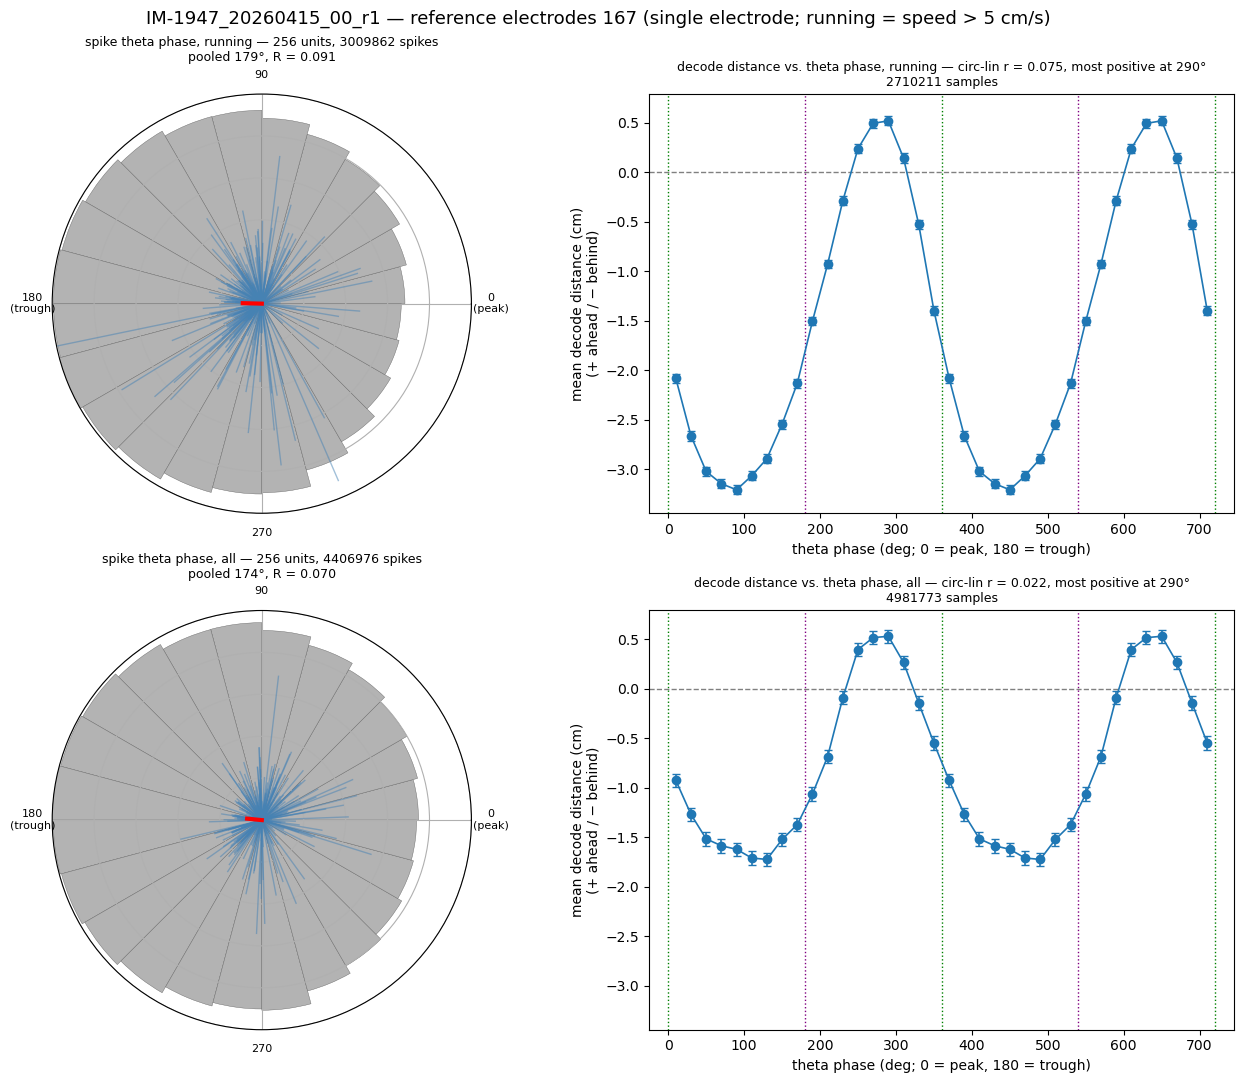

In [10]:
# The electrodes you want to check. Only these are read off disk, so trying another pick costs
# seconds -- run this cell again with a different list.
REFERENCE_ELECTRODES = [167]

# Or take the top of the candidates table, i.e. whichever electrode fires closest to 180 deg:
# REFERENCE_ELECTRODES = [int(candidates.index[0])]

# Or check a set that is already saved:
# REFERENCE_ELECTRODES = (HexMazeThetaReference & {
#     "nwb_file_name": NWB_FILE_NAME, "target_interval_list_name": INTERVAL,
#     "reference_name": "theta_ref_1"}).fetch1("electrode_ids")

evaluation = evaluate_reference(NWB_FILE_NAME, INTERVAL, REFERENCE_ELECTRODES)
fig = plot_reference_evaluation(evaluation, info,
                               save_dir=Path("figures") / info["session_label"])

## Save a reference electrode set

Once you have picked the electrodes, insert them so downstream theta code uses them. The
candidates table ranks electrodes by distance from **180°**; among the top rows prefer a high
**R** and strong **power**.

In [13]:
# from spyglass_hexmaze.hex_maze_theta import HexMazeThetaReference
# HexMazeThetaReference.add_reference(
#     key={"nwb_file_name": "IM-1871_20250805_.nwb", "target_interval_list_name": "00_r1"},
#     reference_name="theta_ref_1",
#     electrode_ids=[130],
#     description="theta reference electrode, hippocampus CA1",
# )


## Every Berke session

Roughly 4 minutes per session, so about 2 hours for all 27. Figures land in
`figures/<session>/`.

In [ ]:
# Every Berke session: the six panels, the ranked candidates, and a reference check figure for
# each of the top few candidates. Figures and CSVs land in figures/<session>/.
#
# Roughly 4 minutes per session for the panels, plus about a minute per candidate check (each one
# re-reads that session's units and decode), so budget ~7 minutes a session and a few hours for
# all of them. Safe to interrupt and re-run: nothing is recomputed from cache, but the combined
# CSV is rewritten after every session, so a partial run keeps everything it finished.
N_TOP_CANDIDATES = 5
FIG_ROOT = Path("figures")
COMBINED_CSV = FIG_ROOT / "theta_reference_candidates.csv"

berke_sessions = sorted(set(
    (HexMazeThetaV1 & "nwb_file_name LIKE 'IM-%'").fetch("nwb_file_name")))
print(f"{len(berke_sessions)} Berke sessions")

summary_rows = []       # one row per (session, candidate electrode), for the combined CSV
failures = {}

for nwb_file_name in berke_sessions:
    try:
        session_metrics, session_info = compute_metrics(nwb_file_name, INTERVAL, verbose=False)
        label = session_info["session_label"]
        save_dir = FIG_ROOT / label
        save_dir.mkdir(parents=True, exist_ok=True)

        # 1. the six probe panels
        plt.close(plot_metrics(session_metrics, session_info, save_dir=save_dir))

        # 2. the full ranked candidate table for this session
        ranked = rank_candidates(session_metrics)
        ranked.to_csv(save_dir / f"{label}_candidates.csv")

        # 3. a reference check figure per top candidate, and its numbers into the combined table
        for rank, electrode in enumerate(ranked.index[:N_TOP_CANDIDATES]):
            evaluation = evaluate_reference(nwb_file_name, INTERVAL, [int(electrode)],
                                           verbose=False)
            plt.close(plot_reference_evaluation(evaluation, session_info, save_dir=save_dir))
            running = evaluation["spike_phase"]["running"]
            decoded = evaluation["decode_distance"]["running"]
            summary_rows.append({
                "session_label": label,
                "nwb_file_name": nwb_file_name,
                "electrode": int(electrode),
                "rank": rank,
                **ranked.loc[electrode].to_dict(),
                # from the reference check: where running spikes land in THIS electrode's theta,
                # and whether decode distance sweeps with its phase
                "ref_spike_phase_deg": running["pooled_phase_deg"],
                "ref_spike_R": running["pooled_R"],
                "ref_n_spikes": running["n_spikes"],
                "ref_dist_corr": decoded["corr"],
                "ref_dist_peak_phase_deg": decoded["peak_phase_deg"],
            })

        # Rewrite the combined CSV as we go, so an interrupted run still leaves a usable file
        pd.DataFrame(summary_rows).to_csv(COMBINED_CSV, index=False)
        print(f"{label}: top {N_TOP_CANDIDATES} = {ranked.index[:N_TOP_CANDIDATES].tolist()}, "
              f"closest {ranked['deg_from_180_run'].iloc[0]:.0f} deg from the trough")
    except Exception as error:
        failures[nwb_file_name] = f"{type(error).__name__}: {error}"
        print(f"{nwb_file_name}: FAILED - {failures[nwb_file_name]}")

print(f"\n{len(berke_sessions) - len(failures)}/{len(berke_sessions)} sessions done, "
      f"combined table -> {COMBINED_CSV}")
for nwb_file_name, message in failures.items():
    print(f"  {nwb_file_name}: {message}")

27 Berke sessions
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_theta_panels.pdf
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_reference_elec_e156.pdf
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_reference_elec_e154.pdf
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_reference_elec_e152.pdf
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_reference_elec_e151.pdf
saved figures/IM-1478_20220719_00_r1/IM-1478_20220719_00_r1_reference_elec_e153.pdf
IM-1478_20220719_00_r1: top 5 = ['156', '154', '152', '151', '153'], closest 0 deg from the trough
saved figures/IM-1478_20220720_00_r1/IM-1478_20220720_00_r1_theta_panels.pdf
saved figures/IM-1478_20220720_00_r1/IM-1478_20220720_00_r1_reference_elec_e184.pdf
saved figures/IM-1478_20220720_00_r1/IM-1478_20220720_00_r1_reference_elec_e185.pdf
saved figures/IM-1478_20220720_00_r1/IM-1478_20220720_00_r1_reference_elec_e165.pdf
saved figures/IM-1478_20220720_00_r1/IM-1478_20220720_00_

## Save the same reference for every session of one rat at once (Frank lab)

In [ ]:

# from spyglass_hexmaze.hex_maze_theta import HexMazeThetaV1, HexMazeThetaReference

# RAT = "Nova"
# ELECTRODE_IDS = [44]

# nwbs, intervals = (HexMazeThetaV1() & f"nwb_file_name LIKE '{RAT}%'").fetch(
#     "nwb_file_name", "target_interval_list_name")

# for nwb_file_name, target_interval_list_name in zip(nwbs, intervals):
#     HexMazeThetaReference.add_reference(
#         key={"nwb_file_name": nwb_file_name,
#              "target_interval_list_name": target_interval_list_name},
#         reference_name="theta_ref_1",
#         electrode_ids=ELECTRODE_IDS,
#         description="theta reference electrode, hippocampus CA1",
#     )

# display(HexMazeThetaReference() & f"nwb_file_name LIKE '{RAT}%'")
